In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tqdm.autonotebook import tqdm
import pandas as pd
import numpy as np
import os
import shlex
import torch

if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from torch.utils.data import DataLoader
from BasisConvolution.util.hyperparameters import defaultHyperParameters, parseHyperParameters, finalizeHyperParameters
from BasisConvolution.util.arguments import parser
from BasisConvolution.sph.sphOps import sphOperationStates
from BasisConvolution.util.dataloader import datasetLoader, processFolder#, DataLoader
from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.hyperparameters import make_hash, toPandaDict
from BasisConvolution.util.network import buildModel, runInference

from BasisConvolution.util.augment import loadAugmentedBatch
from BasisConvolution.util.hybrid_loss import compute_hybrid_loss, compute_psnr

/tmp/ipykernel_93842/1713707730.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


diffSPH not available, will use sphMath for config parsing


In [3]:
hyperParameterDict = defaultHyperParameters()
hyperParameterDict['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
# hyperParameterDict['device'] = 'cpu'
hyperParameterDict['augmentAngle'] = False
hyperParameterDict['augmentJitter'] = False
hyperParameterDict['maxRollOut'] = 0

In [4]:
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'
basisFunction = 'ffourier'
basisTerms = 4
windowFunction = 'None'

architecture = "32 16"

args = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions.L2" --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))
#args = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions.L2" --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1 --hybridLoss --hybridAlpha 0.7 --hybridBeta 0.3'))

hyperParameterDict = parseHyperParameters(args, None)
hyperParameterDict['device'] = 'cuda'
hyperParameterDict['iterations'] = 2**10

train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
print('Dataset has {} samples'.format(len(train_ds)))


print(train_ds.fileFormat)

# print(len(train_ds))
train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
train_iter = iter(train_loader)

finalizeHyperParameters(hyperParameterDict, train_ds)

config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(123, train_ds, hyperParameterDict, unrollLength=0)


Dataset has 12600 samples
newFormat
Unroll length  1  exceeds maximum, limiting to 0


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


In [8]:
database = pd.DataFrame()

models = []

t = None
basisFunctions = ['ffourier', 'linear', 'ffourier_even', 'ffourier_odd', 'chebyshev']
for basisFunction in basisFunctions:
    # for basisTerms in [2,4,8]:
    for basisTerms in [4]:
        for windowFunction in ['None']:
            #args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))
            args = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions.L2" --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1 --hybridLoss --hybridAlpha 0.7 --hybridBeta 0.3'))

            hyperParameterDict = parseHyperParameters(args, None)
            hyperParameterDict['device'] = 'cuda'
            hyperParameterDict['iterations'] = 2**10
            hyperParameterDict['batchSize'] = 8
            # t.


            train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
            # print(len(train_ds))
            train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
            train_iter = iter(train_loader)

            finalizeHyperParameters(hyperParameterDict, train_ds)

            if t is None:
                t = tqdm(range(hyperParameterDict['totalIterations']))
            t.reset( hyperParameterDict['totalIterations'])
            # t.n =
            t.set_description(f'{basisFunction} - {basisTerms} - {windowFunction}')

            # print(hyperParameterDict['progressLabel'])

            model, optimizer, scheduler = buildModel(hyperParameterDict, verbose = False)

            model = model.train()

            iterLosses = []
            iterPSNRs = []
            bdatas = []
            iterMSELosses = []          # Track pure MSE component
            iterCorrelationLosses = []   # Track correlation loss component  
            iterRawCorrelations = []     # Track actual correlation values

            # bdata = next(train_iter)
            for i in (range(hyperParameterDict['totalIterations'])):
                try:
                    bdata = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    bdata = next(train_iter)
                bdatas.append(bdata)
                # print(bdata)
                configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(bdata, train_ds, hyperParameterDict, unrollLength=0)
                # config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(bdata[0], train_ds, hyperParameterDict)

                optimizer.zero_grad()
                
                predictions = runInference(currentStates, configs, model, verbose = False)
                # print(predictions)
                if i % 100 == 0 or i < 10:  # Print first 10 iterations and every 100
                    pred_min = predictions[0].min().item()
                    pred_max = predictions[0].max().item()
                    print(f"[{basisFunction}] Iter {i:4d}: Pred[{pred_min:7.3f}, {pred_max:7.3f}]")
                    
                    # Check for explosion
                    if abs(pred_max) > 5.0:
                        print(f"   EXPLOSION in {basisFunction} at iteration {i}!")
                        print(f"   Range: [{pred_min:.1f}, {pred_max:.1f}]")

                gts = [traj[0]['fluid']['target'] for traj in trajectoryStates]

                if hyperParameterDict.get('hybridLoss', False):
                    # Hybrid loss mode
                    loss_dict = compute_hybrid_loss(
                        predictions, gts,
                        alpha=hyperParameterDict['hybridAlpha'],
                        beta=hyperParameterDict['hybridBeta']
                    )
                    
                    loss = loss_dict['total_loss']
                    losses = loss_dict['individual_mse']  # For compatibility with existing code
                    psnrs = compute_psnr(predictions, gts)
                    psnr = torch.stack(psnrs).mean()
                    
                    # Track additional metrics
                    iterMSELosses.append(loss_dict['mse_loss'].item())
                    iterCorrelationLosses.append(loss_dict['correlation_loss'].item())
                    iterRawCorrelations.append(loss_dict['raw_correlation'].item())
                    
                else:
                    # Standard MSE loss (existing behavior)
                    losses = [torch.nn.functional.mse_loss(prediction, gt) for prediction, gt in zip(predictions, gts)]
                    psnrs = [20 * torch.log10(gt.abs().max()) - 10 * torch.log10(loss) for gt, loss in zip(gts, losses)]
                    loss = torch.stack(losses).mean()
                    psnr = torch.stack(psnrs).mean()

                loss.backward()


                iterLosses.append([l.item() for l in losses])
                iterPSNRs.append([p.item() for p in psnrs])
                optimizer.step()
                if hyperParameterDict.get('hybridLoss', False):
                    t.set_description(f'{bdata} - {hyperParameterDict["progressLabel"]} - Loss: {loss.item():.4e}, MSE: {loss_dict["mse_loss"].item():.4e}, Corr: {loss_dict["raw_correlation"].item():.3f}, PSNR: {psnr.item():.2f}')
                else:
                    t.set_description(f'{bdata} - {hyperParameterDict["progressLabel"]} - Loss: {loss.item():.4e}, PSNR: {psnr.item():.2f}')
                t.update()
                t.refresh()
            dataFrame = pd.DataFrame([toPandaDict(hyperParameterDict)] * len(bdatas))

            dataFrame['batches'] = bdatas
            for b in range(len(bdata)):
                dataFrame['losses_{}'.format(b)] = [iterLosses[i][b] for i in range(len(bdatas))]
                dataFrame['psnrs_{}'.format(b)] = [iterPSNRs[i][b] for i in range(len(bdatas))]

            dataFrame['losses'] = [np.mean(iterLosses[i]) for i in range(len(bdatas))]
            dataFrame['psnrs'] = [np.mean(iterPSNRs[i]) for i in range(len(bdatas))]
            dataFrame['iteration'] = np.arange(len(bdatas))

            # Save hybrid loss metrics if hybrid loss is enabled
            if hyperParameterDict.get('hybridLoss', False):
                dataFrame['mse_component'] = iterMSELosses
                dataFrame['correlation_component'] = iterCorrelationLosses  
                dataFrame['raw_correlation'] = iterRawCorrelations

            database = pd.concat([database, dataFrame], ignore_index = True)
            models.append(model)


Unroll length  1  exceeds maximum, limiting to 0


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


  0%|          | 0/1024 [00:00<?, ?it/s]

[ffourier] Iter    0: Pred[ -0.002,   0.000]
[ffourier] Iter    1: Pred[ -0.008,  -0.001]
[ffourier] Iter    2: Pred[ -0.014,   0.000]
[ffourier] Iter    3: Pred[ -0.016,   0.001]
[ffourier] Iter    4: Pred[ -0.017,  -0.001]
[ffourier] Iter    5: Pred[ -0.020,  -0.001]
[ffourier] Iter    6: Pred[ -0.017,   0.003]
[ffourier] Iter    7: Pred[ -0.017,   0.002]
[ffourier] Iter    8: Pred[ -0.015,   0.005]
[ffourier] Iter    9: Pred[ -0.014,   0.007]
[ffourier] Iter  100: Pred[  0.582,   2.269]
[ffourier] Iter  200: Pred[  0.765,   1.820]
[ffourier] Iter  300: Pred[  0.792,   1.875]
[ffourier] Iter  400: Pred[  0.874,   1.601]
[ffourier] Iter  500: Pred[  0.905,   1.787]
[ffourier] Iter  600: Pred[  0.922,   1.627]
[ffourier] Iter  700: Pred[  1.021,   1.649]
[ffourier] Iter  800: Pred[  1.038,   1.562]
[ffourier] Iter  900: Pred[  1.063,   1.712]
[ffourier] Iter 1000: Pred[  1.045,   1.887]
Unroll length  1  exceeds maximum, limiting to 0
[linear] Iter    0: Pred[ -0.002,  -0.001]


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


...

[ffourier_even] Iter    1: Pred[ -0.008,   0.001]
[ffourier_even] Iter    2: Pred[ -0.011,   0.003]
[ffourier_even] Iter    3: Pred[ -0.014,   0.007]
[ffourier_even] Iter    4: Pred[ -0.018,   0.006]
[ffourier_even] Iter    5: Pred[ -0.016,   0.005]
[ffourier_even] Iter    6: Pred[ -0.018,   0.015]
[ffourier_even] Iter    7: Pred[ -0.016,   0.013]
[ffourier_even] Iter    8: Pred[ -0.014,   0.015]
[ffourier_even] Iter    9: Pred[ -0.016,   0.025]
[ffourier_even] Iter  100: Pred[  0.315,   2.193]
[ffourier_even] Iter  200: Pred[  0.557,   1.974]
[ffourier_even] Iter  300: Pred[  0.808,   1.973]
[ffourier_even] Iter  400: Pred[  0.891,   1.609]
[ffourier_even] Iter  500: Pred[  0.910,   1.834]
[ffourier_even] Iter  600: Pred[  0.929,   1.628]
[ffourier_even] Iter  700: Pred[  1.005,   1.664]
[ffourier_even] Iter  800: Pred[  1.044,   1.557]
[ffourier_even] Iter  900: Pred[  1.046,   1.733]
[ffourier_even] Iter 1000: Pred[  1.048,   1.955]
Unroll length  1  exceeds maximum, limiting to 0
[

/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


[ffourier_odd] Iter    1: Pred[ -0.005,  -0.000]
[ffourier_odd] Iter    2: Pred[ -0.005,  -0.000]
[ffourier_odd] Iter    3: Pred[ -0.006,   0.001]
[ffourier_odd] Iter    4: Pred[ -0.008,   0.001]
[ffourier_odd] Iter    5: Pred[ -0.010,   0.001]
[ffourier_odd] Iter    6: Pred[ -0.012,   0.003]
[ffourier_odd] Iter    7: Pred[ -0.009,   0.004]
[ffourier_odd] Iter    8: Pred[ -0.010,   0.005]
[ffourier_odd] Iter    9: Pred[ -0.010,   0.006]
[ffourier_odd] Iter  100: Pred[  0.614,   2.305]
[ffourier_odd] Iter  200: Pred[  0.825,   2.012]
[ffourier_odd] Iter  300: Pred[  1.037,   1.728]
[ffourier_odd] Iter  400: Pred[  1.090,   1.621]
[ffourier_odd] Iter  500: Pred[  1.063,   1.588]
[ffourier_odd] Iter  600: Pred[  1.102,   1.491]
[ffourier_odd] Iter  700: Pred[  1.091,   1.583]
[ffourier_odd] Iter  800: Pred[  1.071,   1.502]
[ffourier_odd] Iter  900: Pred[  1.059,   1.569]
[ffourier_odd] Iter 1000: Pred[  1.081,   1.685]
Unroll length  1  exceeds maximum, limiting to 0
[chebyshev] Iter    

/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


[chebyshev] Iter    1: Pred[ -0.029,  -0.002]
[chebyshev] Iter    2: Pred[ -0.033,  -0.001]
[chebyshev] Iter    3: Pred[ -0.019,   0.002]
[chebyshev] Iter    4: Pred[ -0.005,   0.015]
[chebyshev] Iter    5: Pred[ -0.033,   0.012]
[chebyshev] Iter    6: Pred[ -0.050,   0.012]
[chebyshev] Iter    7: Pred[ -0.036,   0.014]
[chebyshev] Iter    8: Pred[ -0.034,   0.021]
[chebyshev] Iter    9: Pred[ -0.030,   0.029]
[chebyshev] Iter  100: Pred[  0.309,   2.272]
[chebyshev] Iter  200: Pred[  0.620,   1.774]
[chebyshev] Iter  300: Pred[  0.675,   1.902]
[chebyshev] Iter  400: Pred[  0.770,   1.673]
[chebyshev] Iter  500: Pred[  0.771,   1.708]
[chebyshev] Iter  600: Pred[  0.668,   1.644]
[chebyshev] Iter  700: Pred[  0.888,   1.670]
[chebyshev] Iter  800: Pred[  0.944,   1.664]
[chebyshev] Iter  900: Pred[  0.971,   1.691]
[chebyshev] Iter 1000: Pred[  0.899,   1.853]


In [9]:
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.network import runInference

In [10]:
basisTerms = database['basisTerms'].unique()
basisFunctions = database['basisFunctions'].unique()

print(basisTerms)
print(basisFunctions)

hues = sns.color_palette(n_colors = len(basisFunctions))
linestyles = ['--', '-', ':', '-.']

[4]
['ffourier' 'linear' 'ffourier_even' 'ffourier_odd' 'chebyshev']


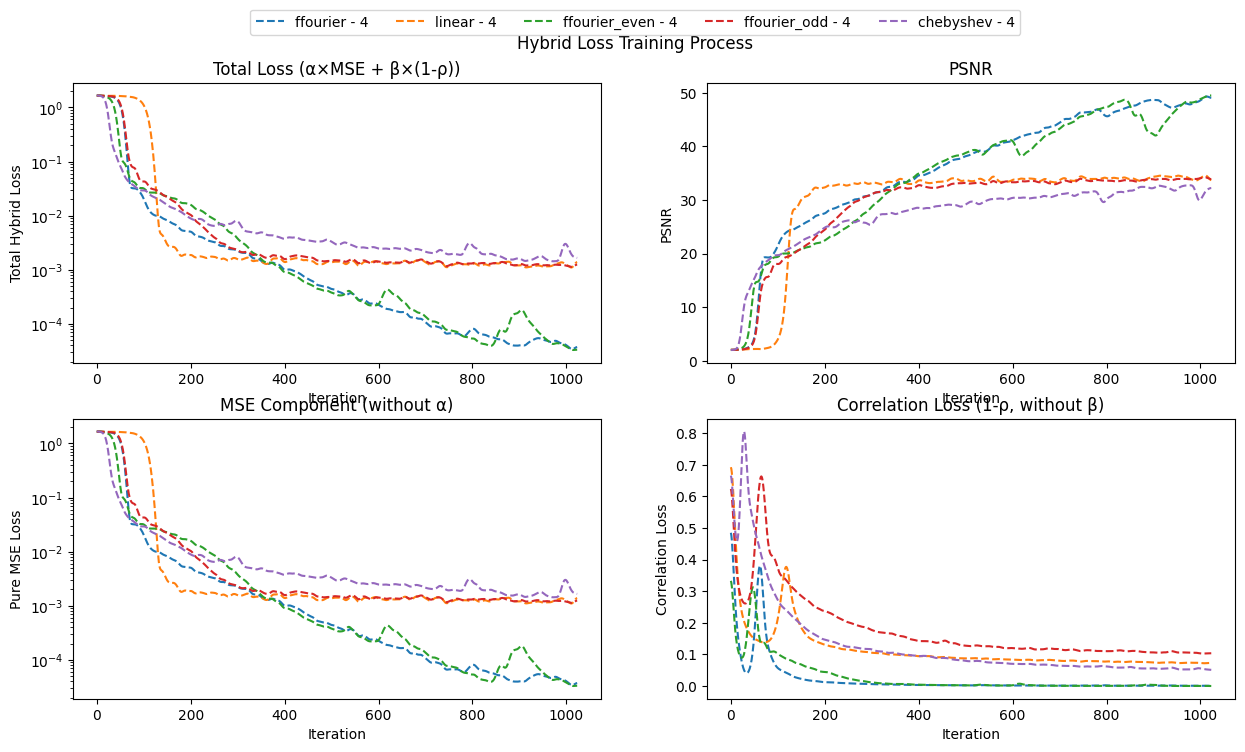

In [11]:
# Check if any model used hybrid loss
hybrid_used = any('mse_component' in database.columns and 
                 database['mse_component'].notna().any() for database in [database])

if hybrid_used:
    # Plot 4 subplots for hybrid loss mode
    fig, axis = plt.subplots(2, 2, figsize=(15, 8), sharey=False, squeeze=False)
    
    for i, basisFunction in enumerate(basisFunctions):
        for j, basisTerm in enumerate(basisTerms):
            subDatabase = database[(database['basisFunctions'] == basisFunction) & (database['basisTerms'] == basisTerm)]
            
            iters = subDatabase['iteration']
            losses = subDatabase['losses']  # Total hybrid loss
            psnrs = subDatabase['psnrs']
            mse_components = subDatabase['mse_component']  # Pure MSE without coefficient
            correlation_components = subDatabase['correlation_component']  # Pure correlation loss without coefficient
            
            # Apply smoothing
            losses = gaussian_filter1d(losses, sigma=5)
            psnrs = gaussian_filter1d(psnrs, sigma=5)
            mse_components = gaussian_filter1d(mse_components, sigma=5)
            correlation_components = gaussian_filter1d(correlation_components, sigma=5)
            
            # Plot total hybrid loss
            axis[0,0].plot(iters, losses, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            
            # Plot PSNR
            axis[0,1].plot(iters, psnrs, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            
            # Plot pure MSE component (without alpha coefficient)
            axis[1,0].plot(iters, mse_components, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            
            # Plot pure correlation loss component (without beta coefficient) 
            axis[1,1].plot(iters, correlation_components, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
    
    # Configure subplots
    axis[0,0].set_yscale('log')
    axis[0,0].set_xlabel('Iteration')
    axis[0,0].set_ylabel('Total Hybrid Loss')
    axis[0,0].set_title('Total Loss (α×MSE + β×(1-ρ))')
    
    axis[0,1].set_xlabel('Iteration')
    axis[0,1].set_ylabel('PSNR')
    axis[0,1].set_title('PSNR')
    
    axis[1,0].set_yscale('log')
    axis[1,0].set_xlabel('Iteration')
    axis[1,0].set_ylabel('Pure MSE Loss')
    axis[1,0].set_title('MSE Component (without α)')
    
    axis[1,1].set_xlabel('Iteration')
    axis[1,1].set_ylabel('Correlation Loss')
    axis[1,1].set_title('Correlation Loss (1-ρ, without β)')
    
    # Add legend
    handles, labels = axis[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.98))
    
    fig.suptitle('Hybrid Loss Training Process', y=0.94)
    fig.subplots_adjust(top=0.88)
    
else:
    # Standard plotting (your current implementation)
    fig, axis = plt.subplots(1, 2, figsize=(10, 4), sharey=False, squeeze=False)
    
    for i, basisFunction in enumerate(basisFunctions):
        for j, basisTerm in enumerate(basisTerms):
            subDatabase = database[(database['basisFunctions'] == basisFunction) & (database['basisTerms'] == basisTerm)]
            
            iters = subDatabase['iteration']
            losses = subDatabase['losses']
            psnrs = subDatabase['psnrs']
            
            losses = gaussian_filter1d(losses, sigma=5)
            psnrs = gaussian_filter1d(psnrs, sigma=5)
            
            axis[0,0].plot(iters, losses, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            axis[0,1].plot(iters, psnrs, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
    
    axis[0,0].set_yscale('log')
    axis[0,0].set_xlabel('Iteration')
    axis[0,0].set_ylabel('Loss')
    
    axis[0,1].set_xlabel('Iteration')
    axis[0,1].set_ylabel('PSNR')
    
    handles, labels = axis[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.95))
    
    fig.suptitle('Training process')
    fig.subplots_adjust(top=0.725)

plt.show()

In [5]:
if len(models) > 0:
    # Save all trained models, using their basis function names if available
    # If basisFunctions is not defined, use generic names
    if 'basisFunctions' in locals():
        basis_names = list(basisFunctions)
    else:
        basis_names = [f'basis_{i}' for i in range(len(models))]
    models_dict = {basis_name: model for basis_name, model in zip(basis_names, models)}

from model_utils import save_model
import torch
import os

basisTerms = 4
windowFunction = 'None'
datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/train'

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/density/32_16"
os.makedirs(save_dir, exist_ok=True)

for basis_name, model in models_dict.items():
    # Use basis_name instead of basisFunction, and explicitly define the other variables
    # ONLY CHANGE: Add hybrid loss parameters to the args
    args_save = parser.parse_args(shlex.split(f'--fluidFeatures "constant:1 attribute:positions.L2" --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --arch "{architecture}" --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))
    model_hyperparams = parseHyperParameters(args_save, None)
    model_hyperparams['device'] = 'cuda'
    model_hyperparams['iterations'] = 2**10
    model_hyperparams['batchSize'] = 8
    train_ds_save = datasetLoader(processFolder(model_hyperparams, datasetPath))
    finalizeHyperParameters(model_hyperparams, train_ds_save)
    
    # ONLY CHANGE: Add the additional hybrid loss info to the save
    torch.save({
        'model_state_dict': model.state_dict(),
        'basis_function': basis_name,
        'hyperparameters': model_hyperparams,
        # Additional hybrid loss parameters
        'hybrid_loss': model_hyperparams.get('hybridLoss', False),
        'hybrid_alpha': model_hyperparams.get('hybridAlpha', 0.7),
        'hybrid_beta': model_hyperparams.get('hybridBeta', 0.3),
        'output_scaling': model_hyperparams.get('outputScaling', 1/128)
    }, f"{save_dir}/{basis_name}_model.pth")

NameError: name 'models' is not defined

In [22]:
import torch
import os
from BasisConvolution.util.network import buildModel

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/lagrangebench_TGV/density/32_16"

models_dict = {}
hyperParameterDict = None

for basis_name in ['ffourier', 'linear', 'chebyshev', 'ffourier_even', 'ffourier_odd']:  # Added missing basis functions
    model_path = f"{save_dir}/{basis_name}_model.pth"
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location='cuda', weights_only=False)
        model_hyperparams = checkpoint['hyperparameters']
        model_hyperparams['device'] = 'cuda'
        
        # ONLY CHANGE: Print hybrid loss info for verification
        if 'hybrid_loss' in checkpoint:
            print(f"Loading {basis_name}: Hybrid Loss = {checkpoint['hybrid_loss']}, α={checkpoint.get('hybrid_alpha', 0.7)}, β={checkpoint.get('hybrid_beta', 0.3)}")
        
        model, _, _ = buildModel(model_hyperparams, verbose=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        models_dict[basis_name] = model
        
        if hyperParameterDict is None:
            hyperParameterDict = model_hyperparams
            
        print(f"Loaded {basis_name} successfully")
    else:
        print(f"Model not found: {model_path}")

print(f"Loaded models: {list(models_dict.keys())}")

Loaded ffourier successfully
Loaded linear successfully
Loaded chebyshev successfully
Loaded ffourier_even successfully
Loaded ffourier_odd successfully
Loaded models: ['ffourier', 'linear', 'chebyshev', 'ffourier_even', 'ffourier_odd']


In [19]:
test_datasetPath = '../../data/SFBC/lagrangebench_dataset_TGV/dataset/test'
test_ds = datasetLoader(processFolder(hyperParameterDict, test_datasetPath))
finalizeHyperParameters(hyperParameterDict, test_ds)

sample_idx = 0
config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(sample_idx, test_ds, hyperParameterDict)

if 'fluid' in currentState:
    fluid_positions = currentState['fluid']['positions']
    num_particles = fluid_positions.shape[0]
    spatial_dims = fluid_positions.shape[1]
    print(f'Number of particles per trajectory: {num_particles:,}')
    print(f'Spatial dimensions: {spatial_dims}D')

import os
import h5py

test_files = [f for f in os.listdir(test_datasetPath) if f.endswith('.hdf5')]
sample_file = os.path.join(test_datasetPath, test_files[0])

with h5py.File(sample_file, 'r') as f:
    if 'simulationExport' in f:
        timestep_groups = [key for key in f['simulationExport'].keys() if key.isdigit()]
        frames_per_trajectory = len(timestep_groups)

total_trajectories = len(test_files)
total_frames_combined = len(test_ds)

print(f'Test trajectories: {total_trajectories}')
print(f'Frames per trajectory: {frames_per_trajectory}')
print(f'Total frames in combined dataset: {total_frames_combined:,}')

import random
random_trajectory_idx = random.randint(0, total_trajectories - 1)
print(f'Selected test trajectory #{random_trajectory_idx}')

finalizeHyperParameters(hyperParameterDict, test_ds)

Unroll length  1  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Number of particles per trajectory: 2,500
Spatial dimensions: 2D
Test trajectories: 50
Frames per trajectory: 126
Total frames in combined dataset: 6,300
Selected test trajectory #40
Unroll length  1  exceeds maximum, limiting to 0


{'coordinateMapping': 'cartesian',
 'windowFunction': 'None',
 'liLoss': 'yes',
 'initialLR': 0.01,
 'finalLR': 0.0001,
 'lrStep': 10,
 'epochs': 1,
 'frameDistance': 0,
 'iterations': 1024,
 'dataDistance': 1,
 'cutoff': 1800,
 'dataLimit': -1,
 'seed': 42,
 'minUnroll': 2,
 'maxUnroll': 0,
 'historyLength': 0,
 'augmentAngle': False,
 'augmentJitter': False,
 'jitterAmount': 0.1,
 'networkSeed': 42,
 'network': 'default',
 'normalized': False,
 'adjustForFrameDistance': True,
 'weight_decay': 0,
 'input': './',
 'output': 'training',
 'loss': 'mse',
 'batchSize': 8,
 'hybridLoss': True,
 'hybridAlpha': 0.7,
 'hybridBeta': 0.3,
 'fluidFeatures': 'constant:1',
 'boundaryFeatures': 'False',
 'boundary': False,
 'groundTruth': 'compute[rho]:constant:1/constant:rho0',
 'gtMode': 'abs',
 'verbose': False,
 'independent_dxdt': False,
 'unrollIncrement': 100,
 'networkType': 'w/o shift',
 'normalization': 'none',
 'skipLastShift': False,
 'shiftLoss': False,
 'activation': 'silu',
 'dataInde

In [20]:
from plotting_utils import *
frames_to_plot = [1, 30, 50, 100, 125]
figsize = (12, 12)
frame_idx = 15

 
print(f"Available models: {list(models_dict.keys())}")
print(f"Plotting frames: {frames_to_plot}")

Available models: ['ffourier', 'linear', 'chebyshev', 'ffourier_even', 'ffourier_odd']
Plotting frames: [1, 30, 50, 100, 125]


Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


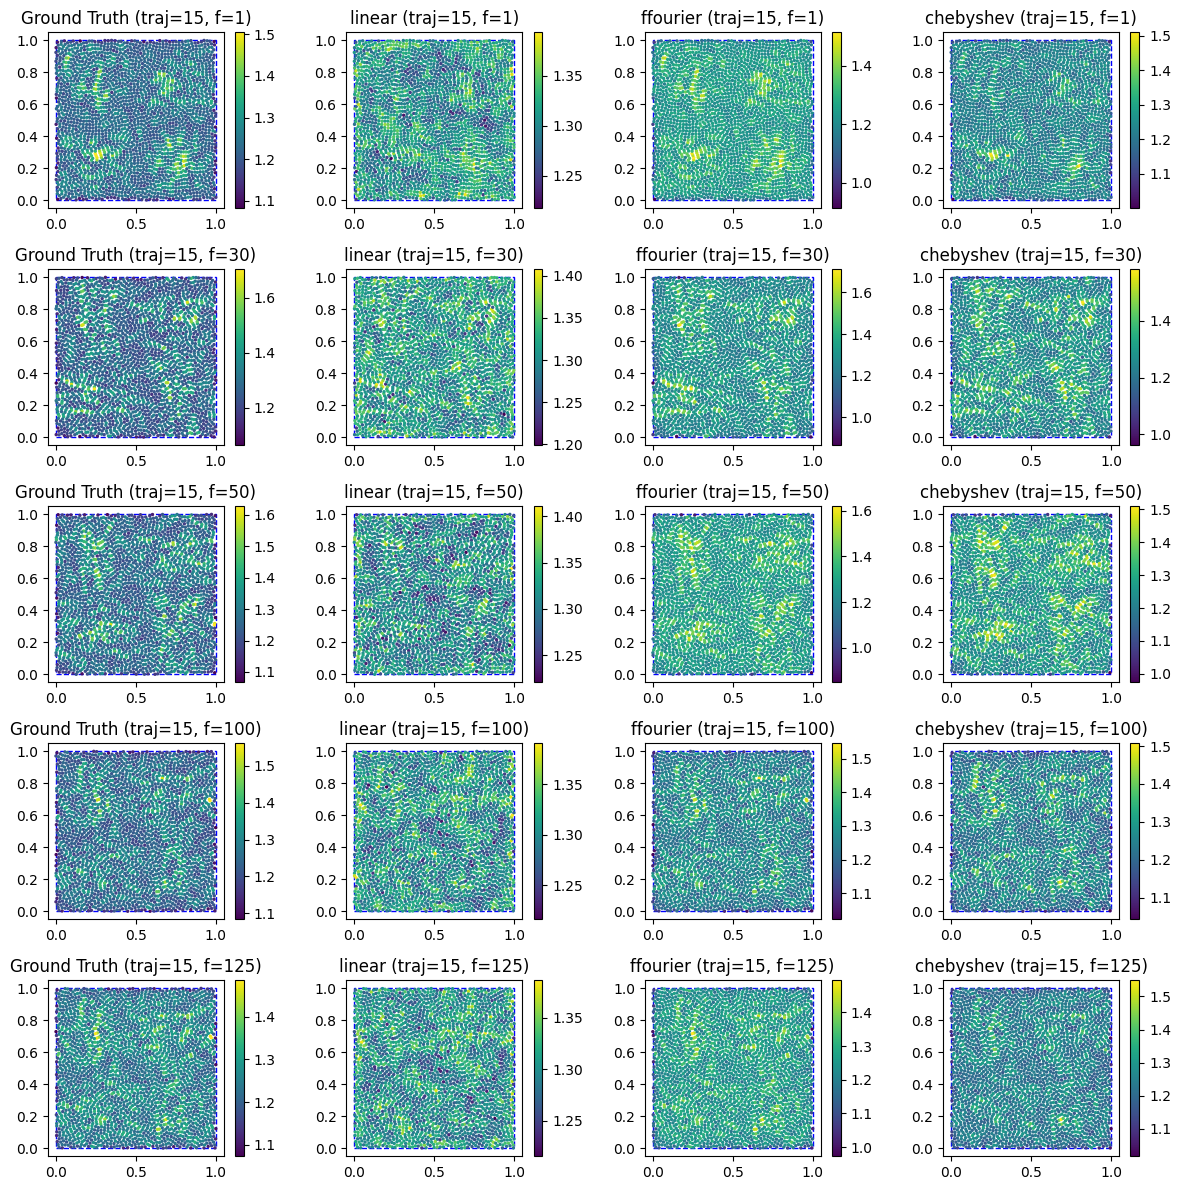

In [16]:
visualize_density_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize,
    frames_per_trajectory=126
)

Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


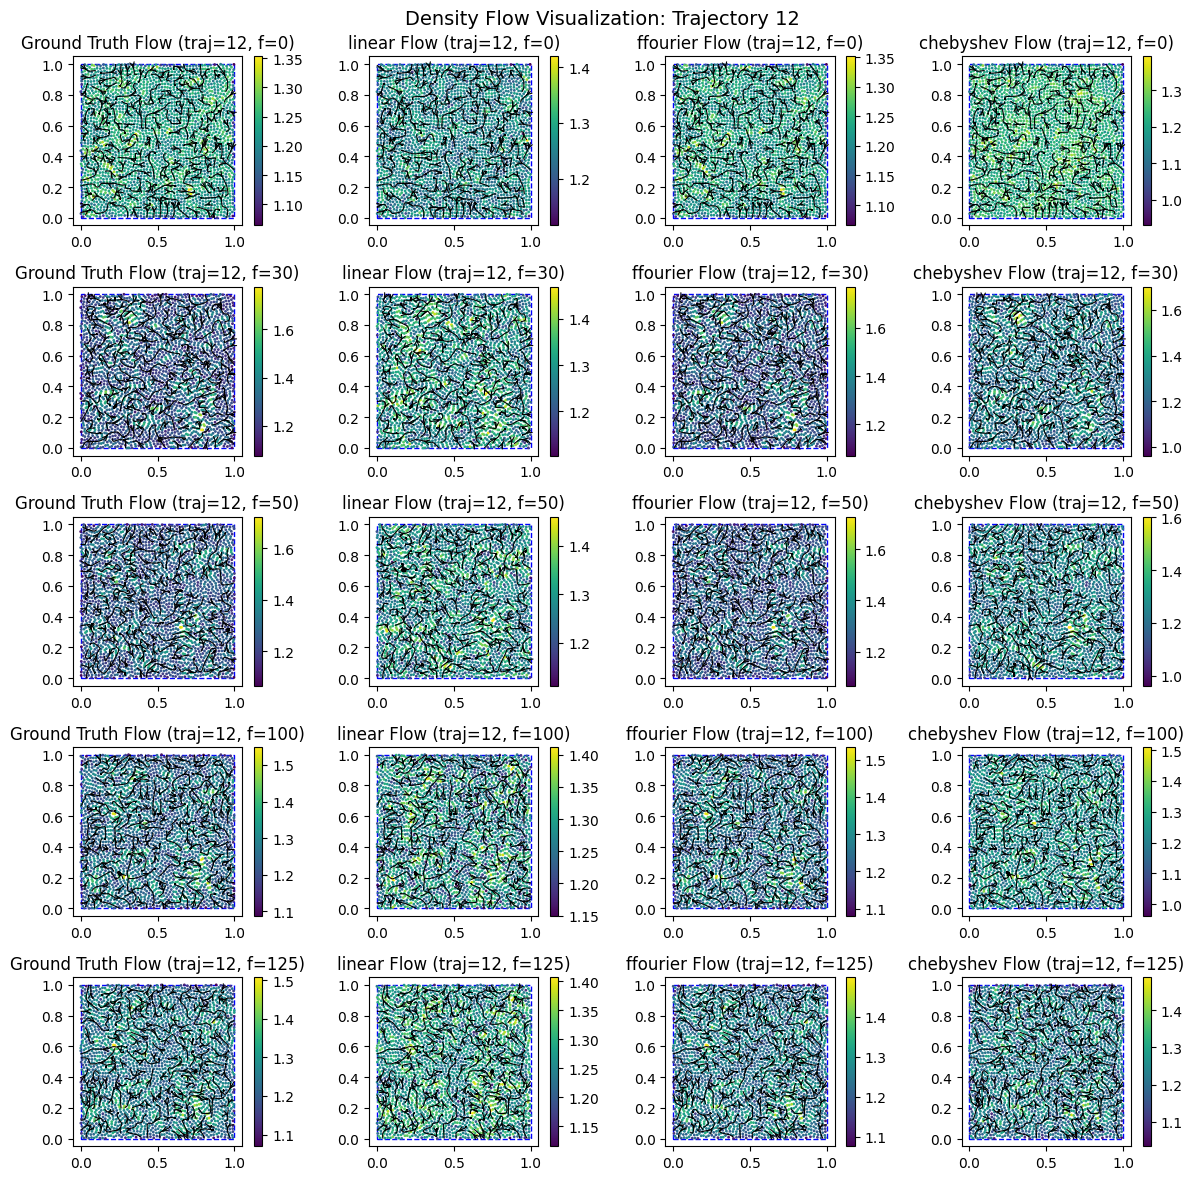

In [14]:
visualize_flow_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize
)

Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


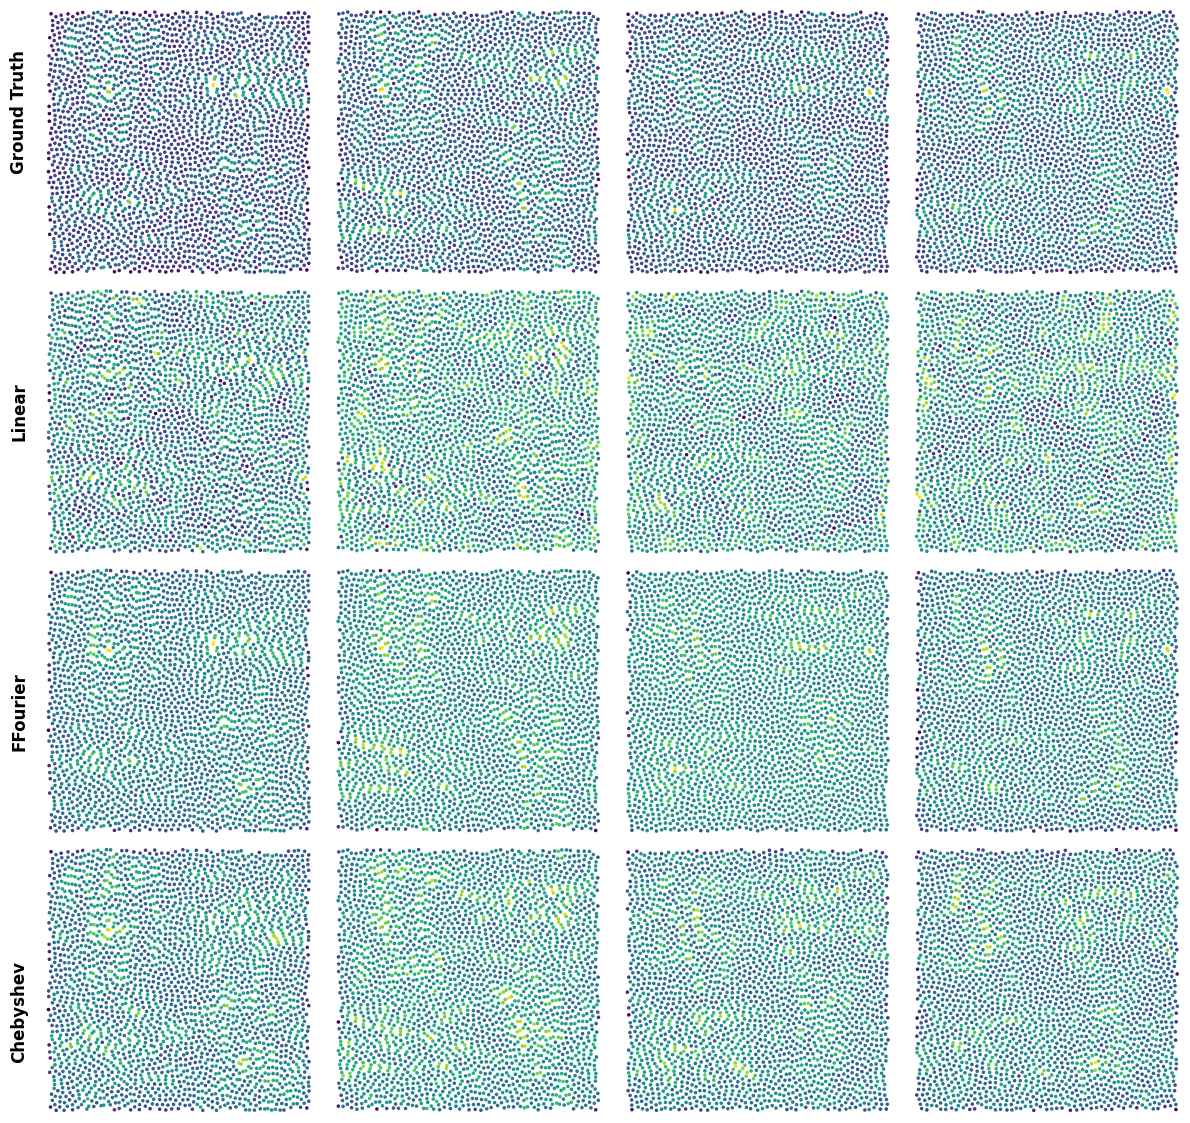

In [23]:
# Clean 4-row density comparison for trajectory 15, frames [10, 30, 70, 100]
visualize_clean_density_comparison(
    models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    trajectory_index=15,
    frames_per_trajectory=126,
    frames=[10, 30, 70, 100],
    figsize=(12, 12)
)